# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)
    print(f"\n{key.upper()}")
    print(f"  Shape: {dfs[key].shape}")
    print(f"  Columns: {list(dfs[key].columns)[:5]}...")


LABORATORY_TESTS
  Shape: (4751, 32)
  Columns: ['hadm_id', 'total_tests', 'n_invalid', 'tests_days_span', 'perc_invalid']...

PROCEDURES
  Shape: (3459, 5)
  Columns: ['subject_id', 'hadm_id', 'total_procedures', 'unique_procedures', 'procedures_days_span']...

HEART_DIAGNOSES
  Shape: (4864, 52)
  Columns: ['subject_id', 'hadm_id', 'age', 'gender', 'lv_dilated']...

MICROBIOLOGY
  Shape: (2756, 12)
  Columns: ['subject_id', 'hadm_id', 'infection_present', 'num_positive_cultures', 'num_unique_organisms']...


## Data Merging

In [5]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (5166, 62)
   Unique patients: 4694


In [6]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (5166, 65)
Unique patients: 4694


In [7]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (5166, 96)
  Unique patients: 4694
  Total admissions: 4761


In [8]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,lv_dilated,wall_motion_abnormality,mitral_regurgitation,aortic_stenosis,pericardial_effusion,rv_dysfunction,...,creat_n,creat_n_abnormal,creat_abnormal_ratio,glu_min,glu_max,glu_n,glu_n_abnormal,glu_abnormal_ratio,glu_var,na_cl_ratio
0,12869457,20004456,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,...,3.0,3.0,1.000000,125.0,193.0,3.0,3.0,1.00,36.936883,1.333333
1,13709807,20007905,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,...,7.0,1.0,0.142857,231.0,314.0,6.0,6.0,1.00,29.846273,1.396423
2,19997460,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,1.0,0.142857,231.0,314.0,6.0,6.0,1.00,29.846273,1.396423
3,19997485,20007905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,1.0,0.142857,231.0,314.0,6.0,6.0,1.00,29.846273,1.396423
4,12002285,20013519,NaN,NaN,1.0,1.0,1.0,0.0,0.0,1.0,...,4.0,4.0,1.000000,74.0,104.0,4.0,1.0,0.25,13.744696,1.345070


In [9]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5166 entries, 0 to 5165
Data columns (total 96 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   subject_id                    5166 non-null   int64  
 1   hadm_id                       5166 non-null   Int64  
 2   age                           1363 non-null   float64
 3   gender                        1363 non-null   object 
 4   lv_dilated                    4285 non-null   float64
 5   wall_motion_abnormality       4285 non-null   float64
 6   mitral_regurgitation          4285 non-null   float64
 7   aortic_stenosis               4285 non-null   float64
 8   pericardial_effusion          4285 non-null   float64
 9   rv_dysfunction                4285 non-null   float64
 10  atrial_fibrillation           3272 non-null   float64
 11  lbbb                          3272 non-null   float64
 12  rbbb                          3272 non-null   float64
 13  st_

## Aggregation of the features at patient level

In this phase, we aggregate the measure reported at admission level to form a patient-wise report. 

For creating the patient profile, we use aggregation rules for the creation of patient-wise features which aggregates measures taken from patient's admission  

In [10]:
# Categorize features by aggregation method
aggregation_rules = {
    # ========== IDENTIFIERS ==========
    'subject_id': 'first',  # Keep patient ID
    
    # ========== DEMOGRAPHICS (take from any admission) ==========
    'age': 'first',         # Age should be consistent across admissions
    'gender': 'first',      # Gender is constant
    
    # ========== BINARY FEATURES (at least once = 1) ==========
    # If condition appears in ANY admission → patient has it
    'lv_dilated': 'max',
    'wall_motion_abnormality': 'max',
    'mitral_regurgitation': 'max',
    'aortic_stenosis': 'max',
    'pericardial_effusion': 'max',
    'rv_dysfunction': 'max',
    'atrial_fibrillation': 'max',
    'lbbb': 'max',
    'rbbb': 'max',
    'st_elevation': 'max',
    'st_depression': 'max',
    'q_waves': 'max',
    'lvh': 'max',
    'perrl': 'max',
    'nad': 'max',
    'rrr_cardiac': 'max',
    'ctab': 'max',
    'crackles_present': 'max',
    'wheezes_present': 'max',
    'murmur_present': 'max',
    'edema_present': 'max',
    'pulmonary_embolism': 'max',
    'pleural_effusion': 'max',
    'pulmonary_edema': 'max',
    'coronary_calcification': 'max',
    'aortic_aneurysm': 'max',
    'aortic_dissection': 'max',
    'coronary_artery_disease': 'max',
    'severe_stenosis': 'max',
    'stent_placed': 'max',
    'low_cardiac_output': 'max',
    'elevated_filling_pressure': 'max',
    
    # ========== CONTINUOUS FEATURES (worst value) ==========
    # For clinical severity: take WORST value across admissions
    'temperature': 'max',           # Fever = worse
    'bp_systolic': 'mean',          # Average BP more stable
    'bp_diastolic': 'mean',
    'heart_rate': 'max',            # Tachycardia = worse
    'respiratory_rate': 'max',      # Tachypnea = worse
    'oxygen_saturation': 'min',     # Hypoxia = worse (lower is worse)
    
    # ========== CARDIAC FUNCTION (worst) ==========
    'lvef': 'min',                  # Lower LVEF = worse
    'cardiac_index': 'min',         # Lower CI = worse
    'pcwp': 'max',                  # Higher PCWP = worse
    
    # ========== CAD SEVERITY (worst) ==========
    'lad_stenosis': 'max',          # Worst stenosis
    'rca_stenosis': 'max',
    'num_vessels_diseased': 'max',  # Most vessels diseased
    
    # ========== COMPOSITE SCORES (worst) ==========
    'heart_failure_severity_score': 'max',
    'cad_severity_score': 'max',
    'risk_category': 'last',        # Most recent assessment
    
    # ========== LABORATORY TESTS (aggregate) ==========
    'total_tests': 'sum',           # Total across all admissions
    'n_invalid': 'sum',             # Total abnormal tests
    'tests_days_span': 'sum',       # Total monitoring days
    'perc_invalid': 'mean',         # Average abnormality rate
    
    # Electrolytes (worst values)
    'k_min': 'min',
    'k_max': 'max',
    'k_n': 'sum',
    'k_abnormal_ratio': 'mean',
    
    'na_min': 'min',
    'na_max': 'max',
    'na_n': 'sum',
    'na_abnormal_ratio': 'mean',
    
    'cl_min': 'min',
    'cl_max': 'max',
    'cl_n': 'sum',
    'cl_abnormal_ratio': 'mean',
    
    'creat_max': 'max',             # Worst kidney function
    'creat_n': 'sum',
    'creat_abnormal_ratio': 'mean',
    
    'glu_max': 'max',               # Worst glucose control
    'glu_n': 'sum',
    'glu_abnormal_ratio': 'mean',
    'glu_var': 'mean',              # Average variability
    
    'na_cl_ratio': 'mean',
    
    # ========== PROCEDURES (aggregate) ==========
    'total_procedures': 'sum',      # Total procedures across admissions
    'unique_procedures': 'sum',     # Sum of unique procedures
    'procedures_days_span': 'sum',
    
    # ========== MICROBIOLOGY (aggregate) ==========
    'infection_present': 'max',     # Ever had infection
    'num_positive_cultures': 'sum',
    'num_unique_organisms': 'sum',
    'days_to_first_positive': 'min',
    'antibiotic_resistant': 'max',
    'resistant_organisms_count': 'sum',
    'fungal_infection': 'max',
    'gram_positive_present': 'max',
    'gram_negative_present': 'max'
}

# Count aggregation strategies
agg_counts = pd.Series(aggregation_rules.values()).value_counts()
print("\nAggregation strategy distribution:")
for method, count in agg_counts.items():
    print(f"  • {method}: {count} features")


Aggregation strategy distribution:
  • max: 51 features
  • sum: 14 features
  • mean: 10 features
  • min: 7 features
  • first: 3 features
  • last: 1 features


Now, we apply this aggregation:

In [11]:
# Filter rules to only include columns present in dataset
valid_rules = {col: method for col, method in aggregation_rules.items() 
               if col in patient_admissions.columns}

print(f"\nFeatures to aggregate: {len(valid_rules)}")
print(f"Features not in dataset: {len(aggregation_rules) - len(valid_rules)}")

# Group by patient and aggregate
patient_profiles = patient_admissions.groupby('subject_id').agg(valid_rules).reset_index(drop=True)

print(f"\n Patient-wise aggregation completed")
print(f"   Original shape (admission-level): {patient_admissions.shape}")
print(f"   Aggregated shape (patient-level): {patient_profiles.shape}")
print(f"   Features per patient: {patient_profiles.shape[1]}")


Features to aggregate: 80
Features not in dataset: 6

 Patient-wise aggregation completed
   Original shape (admission-level): (5166, 96)
   Aggregated shape (patient-level): (4694, 80)
   Features per patient: 80


In [12]:
patient_profiles.head()

,subject_id,age,gender,lv_dilated,wall_motion_abnormality,mitral_regurgitation,aortic_stenosis,pericardial_effusion,rv_dysfunction,atrial_fibrillation,...,glu_n,glu_abnormal_ratio,glu_var,na_cl_ratio,total_procedures,unique_procedures,procedures_days_span,infection_present,num_positive_cultures,num_unique_organisms
0,10000980,75.0,F,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,9.0,0.678571,29.568035,1.326521,7.0,7.0,0.0,0.0,0.0,0.0
1,10002013,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,2.0,1.000000,16.263456,1.382653,2.0,2.0,0.0,NaN,0.0,0.0
2,10002155,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,16.0,0.687500,10.264624,1.337646,8.0,8.0,14.0,0.0,0.0,0.0
3,10004457,66.0,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.000000,NaN,1.361905,0.0,0.0,0.0,NaN,0.0,0.0
4,10007058,48.0,M,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,5.0,0.800000,7.190271,1.339114,2.0,2.0,0.0,0.0,0.0,0.0


## Data Quality Assessment

### Missing values analysis

We calculate missing percentage for each feature

We divide the features into:
- "good" if they have < 20% missing values
- "moderate" if they have a missing rate between 20% and 40%
- "risky" otherwise

In [13]:
# Define thresholds
THRESHOLD_RISKY = 40      # >40% = risky
THRESHOLD_MODERATE = 20   # 20-40% = moderate
# <20% = good

# Missing data analysis
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print(f"  Features with NO missing: {(missing_stats['Missing_Count'] == 0).sum()}")
print(f"  Features with <20% missing: {(missing_stats['Missing_Pct'] < THRESHOLD_MODERATE).sum()}")
print(f"  Features with >40% missing: {(missing_stats['Missing_Pct'] > THRESHOLD_RISKY).sum()}")


  Features with NO missing: 14
  Features with <20% missing: 46
  Features with >40% missing: 26


In [14]:
missing_stats['Category'] = pd.cut(
    missing_stats['Missing_Pct'],
    bins=[-0.1, THRESHOLD_MODERATE, THRESHOLD_RISKY, 100],
    labels=['GOOD', 'MODERATE', 'RISKY']
)

In [15]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                  Feature  Missing_Count  Missing_Pct Category
       low_cardiac_output           4490        95.65    RISKY
            cardiac_index           4490        95.65    RISKY
                     pcwp           4475        95.33    RISKY
elevated_filling_pressure           4475        95.33    RISKY
     num_vessels_diseased           4452        94.84    RISKY
  coronary_artery_disease           4452        94.84    RISKY
             rca_stenosis           3697        78.76    RISKY
                      age           3430        73.07    RISKY
                   gender           3430        73.07    RISKY
             lad_stenosis           3356        71.50    RISKY
                     lvef           3288        70.05    RISKY
            edema_present           3273        69.73    RISKY
        aortic_dissection           3068        65.36    RISKY
          aortic_aneurysm           3068        65.36    RISKY
          pulmonary

### Features removal

We can delete the "risky" features which have a lot of missing values because they are not informative to us at patient level. 

In [16]:
exclude_features = ['subject_id', 'hadm_id', 'dod']

In [17]:
good_features = missing_stats[
    (missing_stats['Category'] == 'GOOD') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

moderate_features = missing_stats[
    (missing_stats['Category'] == 'MODERATE') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

risky_features = missing_stats[
    (missing_stats['Category'] == 'RISKY') & 
    (~missing_stats['Feature'].isin(exclude_features))
]['Feature'].tolist()

In [18]:
critical_moderate = {
    'atrial_fibrillation': 'Strong mortality predictor',
    'lbbb': 'Heart failure marker',
    'st_elevation': 'Acute MI indicator',
    'st_depression': 'Ischemia marker',
    'oxygen_saturation': 'Vital sign',
    'q_waves': 'Old MI marker',
    'temperature': 'Vital sign'
}

moderate_to_keep = [f for f in moderate_features if f in critical_moderate]
moderate_to_remove = [f for f in moderate_features if f not in critical_moderate]

In [19]:
features_to_keep = good_features + moderate_to_keep
features_to_remove = risky_features + moderate_to_remove

In [20]:
df_filtered = patient_profiles[['subject_id'] + features_to_keep].copy()


### Handling missing values on moderate and good features

#### Identify feature types (binary vs continuous)

In [21]:
binary_features = []
continuous_features = []

for col in features_to_keep:
    if col in df_filtered.columns:
        # Check unique non-null values
        unique_vals = df_filtered[col].dropna().unique()
        
        # Binary: only 0 and 1 (or True/False)
        if len(unique_vals) <= 2:
            if all(v in [0, 1, 0.0, 1.0, True, False] for v in unique_vals):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)

In [22]:
print("\n   Binary features (sample):")
for feat in binary_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(binary_features) > 10:
    print(f"      ... and {len(binary_features)-10} more")


   Binary features (sample):
      • lv_dilated                               768 missing
      • rv_dysfunction                           768 missing
      • aortic_stenosis                          768 missing
      • wall_motion_abnormality                  768 missing
      • pericardial_effusion                     768 missing
      • mitral_regurgitation                     768 missing
      • ctab                                     302 missing
      • perrl                                    302 missing
      • wheezes_present                          302 missing
      • crackles_present                         302 missing
      ... and 8 more


In [23]:
print("\n   Continuous features (sample):")
for feat in continuous_features[:10]:
    n_missing = df_filtered[feat].isnull().sum()
    print(f"      • {feat:<40} {n_missing} missing")
if len(continuous_features) > 10:
    print(f"      ... and {len(continuous_features)-10} more")


   Continuous features (sample):
      • glu_var                                  349 missing
      • heart_failure_severity_score             302 missing
      • cad_severity_score                       302 missing
      • risk_category                            302 missing
      • glu_max                                  30 missing
      • glu_abnormal_ratio                       30 missing
      • na_abnormal_ratio                        23 missing
      • na_min                                   23 missing
      • cl_max                                   23 missing
      • na_max                                   23 missing
      ... and 23 more


#### add missingness indicators for moderate features

In [24]:
missingness_indicators = []

for feature in moderate_to_keep:
    if feature in df_filtered.columns:
        # Create indicator: 1 = measured, 0 = not measured
        indicator_name = f'{feature}_measured'
        df_filtered[indicator_name] = (~df_filtered[feature].isnull()).astype(int)
        missingness_indicators.append(indicator_name)
        
        measured = df_filtered[indicator_name].sum()
        not_measured = len(df_filtered) - measured
        
        print(f"  ✓ {indicator_name}")
        print(f"     Measured: {measured} ({measured/len(df_filtered)*100:.1f}%)")
        print(f"     Not measured: {not_measured} ({not_measured/len(df_filtered)*100:.1f}%)")

  ✓ atrial_fibrillation_measured
     Measured: 3023 (64.4%)
     Not measured: 1671 (35.6%)
  ✓ lbbb_measured
     Measured: 3023 (64.4%)
     Not measured: 1671 (35.6%)
  ✓ q_waves_measured
     Measured: 3023 (64.4%)
     Not measured: 1671 (35.6%)
  ✓ st_depression_measured
     Measured: 3023 (64.4%)
     Not measured: 1671 (35.6%)
  ✓ st_elevation_measured
     Measured: 3023 (64.4%)
     Not measured: 1671 (35.6%)
  ✓ oxygen_saturation_measured
     Measured: 3561 (75.9%)
     Not measured: 1133 (24.1%)


Now we can impute missing values.

Let's start from binary features...

In [ ]:
binary_imputation_log = []

for col in binary_features:
    if col in df_filtered.columns:
        n_missing = df_filtered[col].isnull().sum()
        
        if n_missing > 0:
            # Calculate mode
            mode_val = df_filtered[col].mode()[0] if not df_filtered[col].mode().empty else 0
            
            # Impute
            df_filtered[col].fillna(mode_val, inplace=True)
            
            binary_imputation_log.append({
                'Feature': col,
                'Missing_Count': n_missing,
                'Imputed_Value': mode_val
            })
            
            print(f"{col:<40} {n_missing:>4} missing → {int(mode_val)}")

print(f"\nImputed {len(binary_imputation_log)} binary features")

  ✓ lv_dilated                                768 missing → 1
  ✓ rv_dysfunction                            768 missing → 0
  ✓ aortic_stenosis                           768 missing → 0
  ✓ wall_motion_abnormality                   768 missing → 0
  ✓ pericardial_effusion                      768 missing → 0
  ✓ mitral_regurgitation                      768 missing → 1
  ✓ ctab                                      302 missing → 0
  ✓ perrl                                     302 missing → 1
  ✓ wheezes_present                           302 missing → 0
  ✓ crackles_present                          302 missing → 0
  ✓ rrr_cardiac                               302 missing → 0
  ✓ nad                                       302 missing → 1
  ✓ murmur_present                            302 missing → 0
  ✓ atrial_fibrillation                      1671 missing → 0
  ✓ lbbb                                     1671 missing → 0
  ✓ q_waves                                  1671 missing → 0
  ✓ st_d

/tmp/ipykernel_87397/1862060954.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered[col].fillna(mode_val, inplace=True)


And continue with continuous features: we use KNN imputer if there is possibility, otherwise we use median fallback

In [26]:
from sklearn.impute import KNNImputer


if len(continuous_features) > 0:
    continuous_data = df_filtered[continuous_features].copy()
    for col in continuous_data.columns:
        if continuous_data[col].dtype == 'object':
            try:
                continuous_data[col] = pd.to_numeric(continuous_data[col])
            except:
                continuous_features.remove(col)
    
    missing_before = continuous_data.isnull().sum()
    features_with_missing = missing_before[missing_before > 0]
    
    print(f"Features requiring imputation: {len(features_with_missing)}\n")
    
    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
    try:
        continuous_imputed = knn_imputer.fit_transform(continuous_data)
        
        # Update dataframe
        df_filtered[continuous_features] = continuous_imputed
        
        # Log imputation
        for feat in features_with_missing.index:
            print(f"  ✓ {feat:<40} {missing_before[feat]:>4} missing → KNN imputed")
        
        print(f"\nKNN imputation completed for {len(features_with_missing)} continuous features")
        print(f"   Method: k=5 nearest neighbors with distance weighting")
        
    except Exception as e:
        print(f"\nKNN imputation failed: {str(e)}")
        print("   Falling back to median imputation...")
        
        # Fallback: median imputation
        for col in continuous_features:
            if df_filtered[col].isnull().any():
                median_val = df_filtered[col].median()
                df_filtered[col].fillna(median_val, inplace=True)
                print(f"  ✓ {col:<40} imputed with median: {median_val:.2f}")
else:
    print("No continuous features requiring imputation")

Features requiring imputation: 20


KNN imputation failed: could not convert string to float: 'Low'
   Falling back to median imputation...
  ✓ glu_var                                  imputed with median: 20.07
  ✓ heart_failure_severity_score             imputed with median: 1.00
  ✓ cad_severity_score                       imputed with median: 0.00
  ✓ glu_max                                  imputed with median: 149.50
  ✓ glu_abnormal_ratio                       imputed with median: 0.75
  ✓ na_abnormal_ratio                        imputed with median: 0.00
  ✓ na_min                                   imputed with median: 136.00
  ✓ cl_max                                   imputed with median: 105.00
  ✓ na_max                                   imputed with median: 141.00
  ✓ cl_min                                   imputed with median: 100.00
  ✓ na_cl_ratio                              imputed with median: 1.36
  ✓ cl_abnormal_ratio                        imputed with median: 0.

/tmp/ipykernel_87397/3712852280.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered[col].fillna(median_val, inplace=True)


In [42]:
patient_profiles = df_filtered.copy()

## Dimensionality Reduction

In [43]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id']]

In [45]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [46]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
low_variance_features = X.columns[~sel.get_support()].tolist()
print(f"\nLow variance features removed ({len(low_variance_features)}): {low_variance_features}")

X = X.loc[:, sel.get_support()]
print(f"After variance filter: {X.shape[1]} features")



Low variance features removed (3): ['aortic_stenosis', 'pericardial_effusion', 'na_cl_ratio']
After variance filter: 53 features


In [47]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (53, 53)


In [48]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [49]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

                       feature_1               feature_2  correlation
38              q_waves_measured   st_elevation_measured     1.000000
39        st_depression_measured   st_elevation_measured     1.000000
37              q_waves_measured  st_depression_measured     1.000000
36                 lbbb_measured   st_elevation_measured     1.000000
35                 lbbb_measured  st_depression_measured     1.000000
34                 lbbb_measured        q_waves_measured     1.000000
33  atrial_fibrillation_measured   st_elevation_measured     1.000000
32  atrial_fibrillation_measured  st_depression_measured     1.000000
31  atrial_fibrillation_measured        q_waves_measured     1.000000
30  atrial_fibrillation_measured           lbbb_measured     1.000000
7                           na_n                    cl_n     0.999273
2                           na_n                     k_n     0.995463
6                           na_n                 creat_n     0.994998
18                  

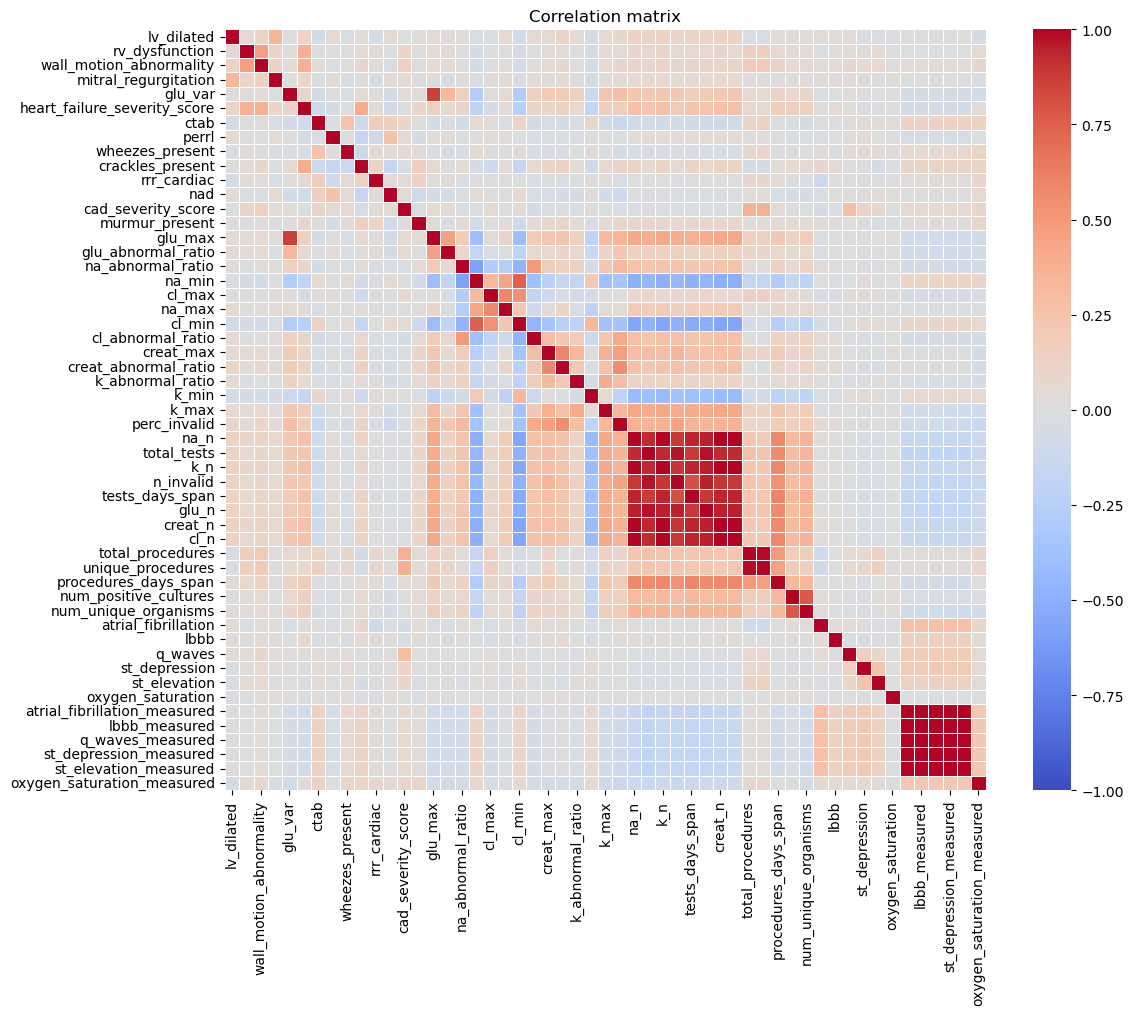

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [51]:
features_to_remove = set()
for _, row in high_corr.iterrows():
    features_to_remove.add(row['feature_2'])

print(f"\nRedundant features ({len(features_to_remove)}):")
for feature in sorted(features_to_remove):
    print(f"  - {feature}")


Redundant features (13):
  - cl_n
  - creat_n
  - glu_max
  - glu_n
  - k_n
  - lbbb_measured
  - n_invalid
  - q_waves_measured
  - st_depression_measured
  - st_elevation_measured
  - tests_days_span
  - total_tests
  - unique_procedures


In [52]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

print(f"Starting features: {len(features_cols)}")
print(f"Features: {features_cols}")

#Remove highly correlated features (threshold 0.80)
corr = X.corr()
high_corr = set()
corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.80:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
            high_corr.add(corr.columns[j])  # Remove the second feature

print(f"\nHighly correlated pairs found (|r| > 0.80): {len(corr_pairs)}")
if len(corr_pairs) > 0:
    print("\nSome examples of high correlations:")
    for feat1, feat2, corr_val in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")

print(f"\nFeatures to remove due to high correlation ({len(high_corr)}): {sorted(high_corr)}")

X = X.drop(columns=list(high_corr), errors='ignore')
print(f"\nAfter correlation filter: {X.shape[1]} features")

# Step 4: Create final dataset
final_features = ['subject_id'] + X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

Starting features: 56
Features: ['lv_dilated', 'rv_dysfunction', 'aortic_stenosis', 'wall_motion_abnormality', 'pericardial_effusion', 'mitral_regurgitation', 'glu_var', 'heart_failure_severity_score', 'ctab', 'perrl', 'wheezes_present', 'crackles_present', 'rrr_cardiac', 'nad', 'cad_severity_score', 'murmur_present', 'glu_max', 'glu_abnormal_ratio', 'na_abnormal_ratio', 'na_min', 'cl_max', 'na_max', 'cl_min', 'na_cl_ratio', 'cl_abnormal_ratio', 'creat_max', 'creat_abnormal_ratio', 'k_abnormal_ratio', 'k_min', 'k_max', 'perc_invalid', 'na_n', 'total_tests', 'k_n', 'n_invalid', 'tests_days_span', 'glu_n', 'creat_n', 'cl_n', 'total_procedures', 'unique_procedures', 'procedures_days_span', 'num_positive_cultures', 'num_unique_organisms', 'atrial_fibrillation', 'lbbb', 'q_waves', 'st_depression', 'st_elevation', 'oxygen_saturation', 'atrial_fibrillation_measured', 'lbbb_measured', 'q_waves_measured', 'st_depression_measured', 'st_elevation_measured', 'oxygen_saturation_measured']

Highly c

In [53]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [54]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [55]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


## Final dataset statistics

In [56]:
print("\n=== FINAL DATASET STATISTICS ===")

print(f"\n Patient Coverage:")
print(f"   Total unique patients: {patient_profiles['subject_id'].nunique()}")
print(f"   Complete cases (no missing): {patient_profiles.dropna().shape[0]}")

# Numeric summary
numeric_final = patient_profiles_clean.select_dtypes(include=[np.number])

print(f"\nNumeric Features Summary:")
summary_stats = numeric_final.describe().round(3)
print(summary_stats.iloc[[1, 2, 3, 4, 5, 7]].T.head(15))


=== FINAL DATASET STATISTICS ===

 Patient Coverage:
   Total unique patients: 4694
   Complete cases (no missing): 4392

Numeric Features Summary:
                                      mean          std         min  \
subject_id                    1.544012e+07  3089376.428  10000980.0   
lv_dilated                    6.740000e-01        0.469         0.0   
rv_dysfunction                1.840000e-01        0.387         0.0   
wall_motion_abnormality       4.140000e-01        0.493         0.0   
mitral_regurgitation          7.630000e-01        0.425         0.0   
glu_var                       2.764100e+01       26.134         0.0   
heart_failure_severity_score  1.395000e+00        1.620         0.0   
ctab                          2.670000e-01        0.443         0.0   
perrl                         6.610000e-01        0.473         0.0   
wheezes_present               2.510000e-01        0.433         0.0   
crackles_present              3.770000e-01        0.485         0.0   

In [ ]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
patient_profiles_clean.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)